# LeetCode 题：[**64. 最小路径和 (Minimum Path Sum)**](https://leetcode.cn/problems/minimum-path-sum/)

**题目描述：**  
给定一个包含非负整数的 m x n 网格 grid ，请找出一条从左上角到右下角的路径，使得路径上的数字总和为最小。每次只能向下或者向右移动一步。

```py
grid = np.array([
        [1, 3, 1, 2],
        [1, 5, 1, 3],
        [4, 2, 1, 1],
        [2, 1, 2, 1]
    ])
```


In [24]:
import numpy as np
import time
import matplotlib.pyplot as plt
from itertools import product
import jax
import jax.numpy as jnp

#### 1. 暴力枚举（Brute Force）
- **思路**：枚举所有可能的路径（每次只能向右或向下），计算每条路径的总和，取最小值。
- **优点**：思路直观，能保证找到全局最优解。
- **缺点**：时间复杂度指数级（O(C(m+n-2, m-1))），只适合非常小的网格，实际应用极慢。

In [25]:
def brute_force_min_path(grid):
    """
    穷举所有路径，返回最小路径和（只能向右或向下走）
    只适合小规模网格
    """
    m, n = grid.shape
    steps = ['D'] * (m - 1) + ['R'] * (n - 1)
    from itertools import permutations
    min_sum = float('inf')
    best_path = None
    # set(permutations(...)) 去重
    for moves in set(permutations(steps)):
        i = j = 0
        path_sum = grid[0, 0]
        for move in moves:
            if move == 'D':
                i += 1
            else:
                j += 1
            path_sum += grid[i, j]
        if path_sum < min_sum:
            min_sum = path_sum
            best_path = moves
    return min_sum, best_path

#### 2. 动态规划（DP）
- **思路**：每个格子的最优解只依赖于上方和左方的最优解，递推填表，每个状态只计算一次。
- **优点**：高效，时间复杂度O(m×n)，空间复杂度O(m×n)（可优化为O(n)）。
- **缺点**：只适用于有最优子结构和无后效性的结构化问题。

In [26]:
def min_path_sum(grid):
    """
    动态规划求解从左上到右下的最短路径和（只能向右或向下走）
    grid: 2D numpy array
    """
    m, n = grid.shape
    dp = np.zeros((m, n), dtype=int)
    dp[0, 0] = grid[0, 0]
    # 初始化第一行和第一列
    for i in range(1, m):
        dp[i, 0] = dp[i-1, 0] + grid[i, 0]
    for j in range(1, n):
        dp[0, j] = dp[0, j-1] + grid[0, j]
    # 填充DP表
    for i in range(1, m):
        for j in range(1, n):
            dp[i, j] = min(dp[i-1, j], dp[i, j-1]) + grid[i, j]
    return dp[m-1, n-1], dp

#### 3. 值迭代（Value Iteration）
- **思路**：全局反复更新每个状态的值，直到所有状态的值收敛。每轮用Bellman方程更新所有格子的最优值。
- **优点**：思想通用，适用于更一般的马尔可夫决策过程（MDP）和强化学习问题。
- **缺点**：每轮都要遍历所有状态，直到收敛。对于本题，理论上最多m+n-2轮收敛，效率略低于DP，但更通用。

In [27]:
def value_iteration_min_path(grid, gamma=1.0, theta=1e-6, max_iterations=10000):
    """
    用值迭代求解从左上到右下的最短路径和（只能向右或向下走）
    """
    m, n = grid.shape
    V = np.full((m, n), np.inf)
    V[-1, -1] = grid[-1, -1]  # 终点的值就是自身代价

    for it in range(max_iterations):
        prev_V = V.copy()
        for i in reversed(range(m)):
            for j in reversed(range(n)):
                if (i, j) == (m-1, n-1):
                    continue
                candidates = []
                if i+1 < m:
                    candidates.append(V[i+1, j])
                if j+1 < n:
                    candidates.append(V[i, j+1])
                if candidates:
                    V[i, j] = grid[i, j] + min(candidates)
        if np.max(np.abs(prev_V - V)) < theta:
            # print(f"值迭代在第 {it+1} 次迭代后收敛")
            break
    return V[0, 0], V

**总结对比：**
- 暴力枚举：最慢，只适合小规模，保证最优。
- 动态规划：最快，结构化问题首选，保证最优。
- 值迭代：思想更通用，适合模型已知的MDP或强化学习，效率略低于DP，但也能保证最优。

---

**值迭代（Value Iteration, VI）理论简介：**

  对于每个状态 s，  
  $$ V_{k+1}(s) = \min_{a} \left[ c(s, a) + \gamma \sum_{s'} P(s'|s,a) V_k(s') \right] $$
  其中 $c(s, a)$ 是代价，$\gamma$ 是折扣因子，$P(s'|s,a)$ 是转移概率。
- **收敛性**：不断全局同步更新，直到所有状态的值几乎不再变化（达到收敛阈值）。
- **最优策略**：收敛后，每个状态选择使右侧最小的动作即为最优策略。

**m+n-2收敛条件**
- 网格为 m×n，且只能向右或向下移动
- **状态转移是确定性的**
- 每轮全局同步更新所有状态
- **没有回环或负权环**
- 终点的值初始化为自身代价
- 每轮迭代都用最新的值函数更新全体状态

In [28]:
def plot_grid_path(grid, dp):
    m, n = grid.shape
    # 回溯最短路径
    path = [(m-1, n-1)]
    i, j = m-1, n-1
    while (i, j) != (0, 0):
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            if dp[i-1, j] < dp[i, j-1]:
                i -= 1
            else:
                j -= 1
        path.append((i, j))
    path = path[::-1]

    fig, ax = plt.subplots()
    ax.imshow(np.ones_like(grid), cmap='gray', vmin=0, vmax=1)
    for i in range(m):
        for j in range(n):
            ax.text(j, i, str(grid[i, j]), va='center', ha='center', color='black')
    y, x = zip(*path)
    ax.plot(x, y, color='red', linewidth=2, marker='o')
    ax.set_xticks(np.arange(-0.5, n, 1))
    ax.set_yticks(np.arange(-0.5, m, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True, which='both', color='black', linewidth=1)
    plt.title("最短路径可视化")
    plt.show()

穷举最短路径和: 9
穷举最优路径: ('R', 'R', 'D', 'D', 'R', 'D')
穷举耗时: 0.000062 秒
DP最短路径和: 9
DP耗时: 0.000012 秒
值迭代最短路径和: 9.0
值迭代耗时: 0.000082 秒


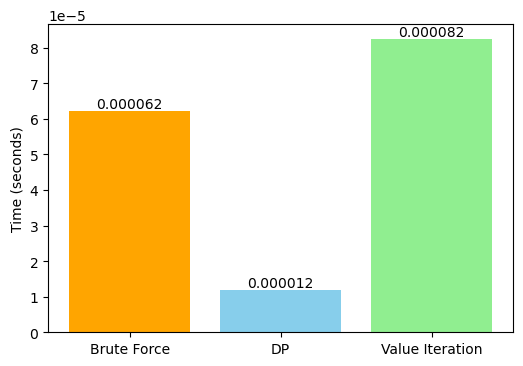

In [29]:
if __name__ == "__main__":
    grid = np.array([
        [1, 3, 1, 2],
        [1, 5, 1, 3],
        [4, 2, 1, 1],
        [2, 1, 2, 1]
    ])
    # grid = np.random.randint(0, 10, size=(50, 50))


    times = []

    start = time.time()
    min_sum, best_path = brute_force_min_path(grid)
    t1 = time.time() - start
    print("穷举最短路径和:", min_sum)
    print("穷举最优路径:", best_path)
    print("穷举耗时: %.6f 秒" % t1)
    times.append(t1)

    start = time.time()
    min_sum, dp_table = min_path_sum(grid)
    t2 = time.time() - start
    print("DP最短路径和:", min_sum)
    print("DP耗时: %.6f 秒" % t2)
    times.append(t2)

    start = time.time()
    min_sum, V_table = value_iteration_min_path(grid)
    t3 = time.time() - start
    print("值迭代最短路径和:", min_sum)
    print("值迭代耗时: %.6f 秒" % t3)
    times.append(t3)

    # 画柱状图
    plt.figure(figsize=(6,4))
    names = ['Brute Force', 'DP', 'Value Iteration']
    plt.bar(names, times, color=['orange', 'skyblue', 'lightgreen'])
    plt.ylabel('Time (seconds)')
    for i, v in enumerate(times):
        plt.text(i, v, f"{v:.6f}", ha='center', va='bottom')
    plt.show()

In [30]:

@jax.jit
def value_iteration_min_path_jax(grid):
    m, n = grid.shape

    # 初始化 V，终点等于自身代价
    V = jnp.full((m, n), jnp.inf).at[-1, -1].set(grid[-1, -1])

    # 从右下角往左上角动态规划
    def body_fun(carry, _):
        V = carry
        # 向下候选（shift up）
        down = jnp.roll(V, -1, axis=0)
        down = down.at[-1, :].set(jnp.inf)
        # 向右候选（shift left）
        right = jnp.roll(V, -1, axis=1)
        right = right.at[:, -1].set(jnp.inf)
        # 更新
        newV = jnp.minimum(down, right) + grid
        newV = newV.at[-1, -1].set(grid[-1, -1])
        return newV, None

    # 迭代 m+n-2 次即可收敛（最长路径长度）
    V_final, _ = jax.lax.scan(body_fun, V, xs=None, length=m+n-2)
    return V_final[0, 0], V_final

In [31]:
def benchmark(grid_np, run_brute_force=False):
    """
    Benchmark different pathfinding algorithms on the given grid.
    
    Parameters:
    grid_np (numpy.ndarray): The grid to run the algorithms on
    run_brute_force (bool): Whether to run the brute force algorithm (default: False)
    
    Returns:
    dict: A dictionary containing the results of each algorithm
    """
    # Convert grid to JAX array
    grid_jnp = jnp.array(grid_np, dtype=jnp.float32)
    
    # print("Grid shape:", grid_np.shape)
    # print("JAX array info:")
    # print("  - dtype:", grid_jnp.dtype)
    # print("  - shape:", grid_jnp.shape)
    # print("  - has inf:", jnp.isinf(grid_jnp).any())
    # print("  - has nan:", jnp.isnan(grid_jnp).any())
    
    times = []
    names = []
    results = {}
    
    # Brute Force (if enabled)
    if run_brute_force:
        names.append('Brute Force')
        start = time.time()
        min_sum, best_path = brute_force_min_path(grid_np)
        t = time.time() - start
        times.append(t)
        results['brute_force'] = {'min_sum': min_sum, 'best_path': best_path, 'time': t}
        print(f"Brute Force min path sum: {min_sum}")
        print(f"Brute Force time: {t:.6f} seconds")
    else:
        names.append('Brute Force (skipped)')
        times.append(0)
        results['brute_force'] = {'min_sum': None, 'time': 0}
        print("Brute Force: Skipped (would be too slow)")

    # Dynamic Programming
    names.append('DP')
    start = time.time()
    min_sum, dp_table = min_path_sum(grid_np)
    t = time.time() - start
    times.append(t)
    results['dp'] = {'min_sum': min_sum, 'time': t}
    print(f"DP min path sum: {min_sum}")
    print(f"DP time: {t:.6f} seconds")

    # Value Iteration (NumPy)
    names.append('Value Iteration')
    start = time.time()
    min_sum, v_table = value_iteration_min_path(grid_np)
    t = time.time() - start
    times.append(t)
    results['value_iteration'] = {'min_sum': min_sum, 'time': t}
    print(f"Value Iteration min path sum: {min_sum}")
    print(f"Value Iteration time: {t:.6f} seconds")

    # JAX Value Iteration
    # Compilation time
    names.append('JAX Compile')
    start = time.time()
    vi_jax_compiled = jax.jit(value_iteration_min_path_jax)
    compile_time = time.time() - start
    times.append(compile_time)
    print(f"JAX compilation time: {compile_time:.6f} seconds")

    # Warmup to ensure compilation
    result = vi_jax_compiled(grid_jnp)
    result[0].block_until_ready()

    # Execution time
    names.append('JAX Run')
    start = time.time()
    min_sum_jax, v_result = vi_jax_compiled(grid_jnp)
    min_sum_jax.block_until_ready()
    run_time = time.time() - start
    times.append(run_time)
    results['jax_value_iteration'] = {
        'min_sum': float(min_sum_jax), 
        'compile_time': compile_time,
        'run_time': run_time
    }
    print(f"JAX Value Iteration min path sum: {float(min_sum_jax)}")
    print(f"JAX execution time: {run_time:.6f} seconds")

    # Plot results
    plt.figure(figsize=(10, 5))
    colors = ['orange', 'skyblue', 'lightgreen', 'gray', 'purple']
    plt.bar(names, times, color=colors[:len(names)])
    plt.ylabel('Time (seconds)')
    for i, v in enumerate(times):
        plt.text(i, v, f"{v:.6f}", ha='center', va='bottom')
    plt.show()
    
    return results



Running benchmark on small grid (4x4):
Brute Force min path sum: 9
Brute Force time: 0.000067 seconds
DP min path sum: 9
DP time: 0.000010 seconds
Value Iteration min path sum: 9.0
Value Iteration time: 0.000066 seconds
JAX compilation time: 0.000128 seconds
JAX Value Iteration min path sum: 9.0
JAX execution time: 0.000147 seconds


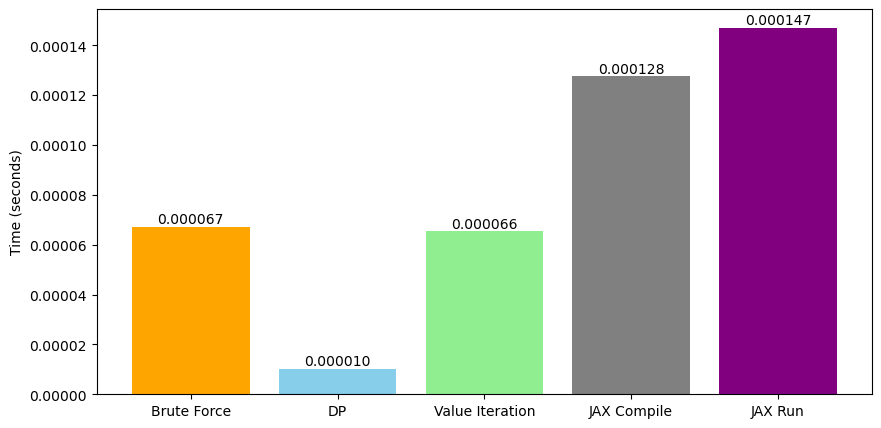


Running benchmark on medium grid (10x10):
Brute Force: Skipped (would be too slow)
DP min path sum: 128
DP time: 0.000287 seconds
Value Iteration min path sum: 128.0
Value Iteration time: 0.001018 seconds
JAX compilation time: 0.000110 seconds
JAX Value Iteration min path sum: 128.0
JAX execution time: 0.000552 seconds


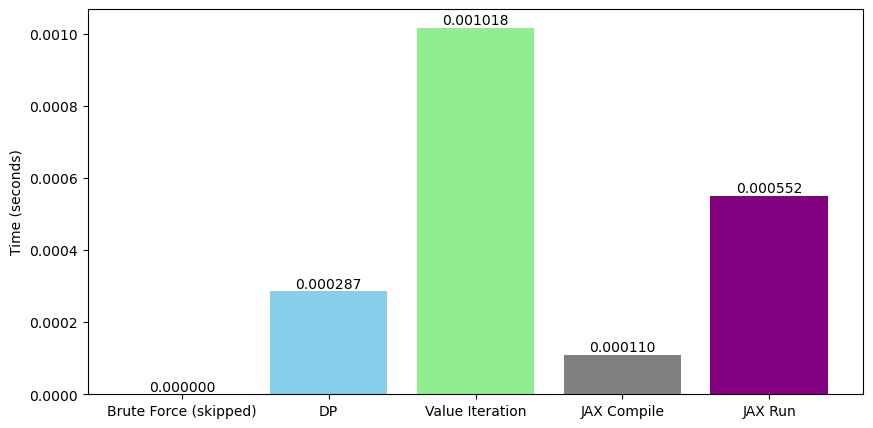


Running benchmark on large grid (1200x1200):
Brute Force: Skipped (would be too slow)
DP min path sum: 4955
DP time: 0.467909 seconds
Value Iteration min path sum: 4955.0
Value Iteration time: 1.684758 seconds
JAX compilation time: 0.000171 seconds
JAX Value Iteration min path sum: 4955.0
JAX execution time: 0.055583 seconds


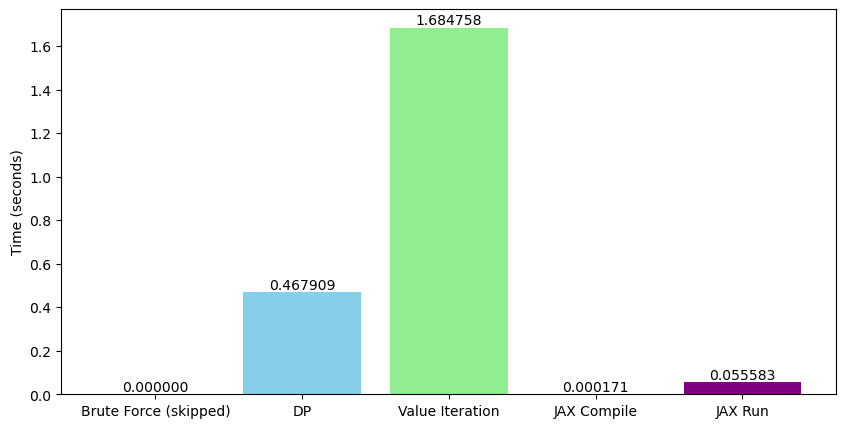

In [32]:
if __name__ == "__main__":
    # Small grid example
    small_grid = np.array([
        [1, 3, 1, 2],
        [1, 5, 1, 3],
        [4, 2, 1, 1],
        [2, 1, 2, 1]
    ])
    print("Running benchmark on small grid (4x4):")
    benchmark(small_grid, run_brute_force=True)
    
    # Medium grid example
    medium_grid = np.random.randint(0, 10, size=(30, 30))
    print("\nRunning benchmark on medium grid (10x10):")
    benchmark(medium_grid, run_brute_force=False)
    
    # Large grid example
    large_grid = np.random.randint(0, 10, size=(1200, 1200))
    print("\nRunning benchmark on large grid (1200x1200):")
    benchmark(large_grid, run_brute_force=False)


### 代码分析


```python
@jax.jit   # ✅ 1. JIT 编译
def value_iteration_min_path_jax(grid):
```

- 把整个函数编译成 XLA 计算图。
- 避免 Python 循环开销，后续所有运算会融合成设备端并行 kernel。

---

```python
V = jnp.full((m, n), jnp.inf).at[-1, -1].set(grid[-1, -1])
```

- 初始化矩阵。
- `.at[-1, -1].set(...)` 在 JAX 里是 **批量更新**，可以并行写入，不是 NumPy 那样逐元素赋值。

---

```python
down = jnp.roll(V, -1, axis=0)
down = down.at[-1, :].set(jnp.inf)
```

- 生成“下方候选值”。
- `jnp.roll` 在 JAX 中是 **并行内存重排**，并且 `.set` 会和 roll 融合在同一个 kernel 里 → 避免创建多个中间数组。

---

```python
right = jnp.roll(V, -1, axis=1)
right = right.at[:, -1].set(jnp.inf)
```

- 生成“右方候选值”。
- 同上 → **整行批量更新**，避免 Python for 循环。

---

```python
newV = jnp.minimum(down, right) + grid
```

- 取最小候选并加上代价。
- `minimum` 和 `+` 都是 **elementwise 运算**，在 JAX 中会被 **融合成单个并行 kernel**，一次性处理整个矩阵。

---

```python
V_final, _ = jax.lax.scan(body_fun, V, xs=None, length=m+n-2)
```

- 循环迭代更新。
- `lax.scan` 会把 **整个循环展开进 XLA 计算图**，避免 Python 逐步进入循环，每次迭代都在设备端并行执行。
